Перші рядки датасету:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Колонки:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

Баланс класів:
target
1    165
0    138
Name: count, dtype: int64

Баланс класів (%):
target
1    54.455446
0    45.544554
Name: proportion, dtype: float64

Архітектура моделі:
Sequential(
  (0): Linear(in_features=13, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)
Епоха 1/30 | Loss=0.6937 | Accuracy=0.4587
Епоха 2/30 | Loss=0.6920 | Accuracy=0.4628
Епоха 3/30 | Loss=0.6903 | Accuracy=0.4711
Епоха 4/30 | Loss=0.6886 | Accuracy=0.4752
Епоха 5/30 | Loss=0.6869 | Accuracy=0.4793
Епоха 6/30 | Loss=0.6852 | Accuracy=0.4793
Епоха 7/30 | Loss=0.6835 | Accuracy=0.4959
Епоха 8/30 | Loss=0.6817 | Accuracy=0.5083
Епоха 9/30 | Loss=0.6800 | Accuracy=0.5289
Епоха 10/30 | Loss=0.6782 | Accuracy=0.

,Метрика,Значення
0,Loss,0.644797
1,Accuracy,0.721311


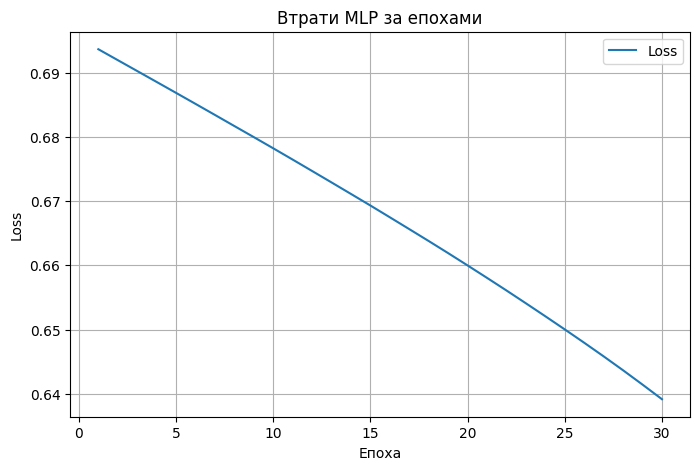

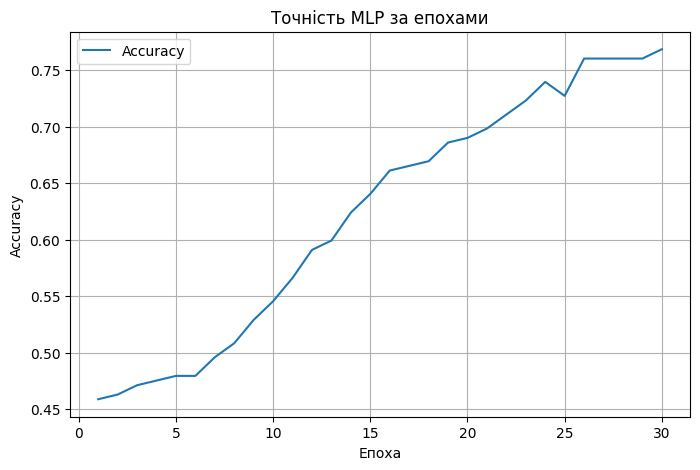


Висновок:
Якщо Loss зменшується, а Accuracy зростає, то модель успішно навчається і покращує якість класифікації.


In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



df = pd.read_csv("heart.csv")

print("Перші рядки датасету:")
display(df.head())

print("\nКолонки:")
print(df.columns)

X = df.drop("target", axis=1)
y = df["target"]

print("\nБаланс класів:")
print(y.value_counts())

print("\nБаланс класів (%):")
print(y.value_counts(normalize=True) * 100)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).view(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).view(-1, 1)



input_size = X_train_scaled.shape[1]

model = nn.Sequential(
    nn.Linear(input_size, 16),
    nn.ReLU(),

    nn.Linear(16, 8),
    nn.ReLU(),

    nn.Linear(8, 1),
    nn.Sigmoid()
)

print("\nАрхітектура моделі:")
print(model)


criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 30

loss_history = []
accuracy_history = []

for epoch in range(epochs):

    model.train()

    y_pred = model(X_train_tensor)

    loss = criterion(
        y_pred,
        y_train_tensor
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():

        predicted_classes = (
            y_pred >= 0.5
        ).float()

        accuracy = (
            predicted_classes
            == y_train_tensor
        ).float().mean()

    loss_history.append(loss.item())
    accuracy_history.append(accuracy.item())

    print(
        f"Епоха {epoch+1}/{epochs} | "
        f"Loss={loss.item():.4f} | "
        f"Accuracy={accuracy.item():.4f}"
    )



model.eval()

with torch.no_grad():

    test_pred = model(X_test_tensor)

    test_loss = criterion(
        test_pred,
        y_test_tensor
    )

    test_classes = (
        test_pred >= 0.5
    ).float()

    test_accuracy = (
        test_classes
        == y_test_tensor
    ).float().mean()

metrics = pd.DataFrame({
    "Метрика": [
        "Loss",
        "Accuracy"
    ],
    "Значення": [
        test_loss.item(),
        test_accuracy.item()
    ]
})

print("\nПідсумкові метрики:")
display(metrics)


plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    label="Loss"
)

plt.xlabel("Епоха")
plt.ylabel("Loss")
plt.title("Втрати MLP за епохами")

plt.legend()
plt.grid(True)

plt.savefig(
    "loss_healthrisk_mlp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    accuracy_history,
    label="Accuracy"
)

plt.xlabel("Епоха")
plt.ylabel("Accuracy")
plt.title("Точність MLP за епохами")

plt.legend()
plt.grid(True)

plt.savefig(
    "accuracy_healthrisk_mlp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



print(
    "\nВисновок:"
    "\nЯкщо Loss зменшується, а Accuracy "
    "зростає, то модель успішно навчається "
    "і покращує якість класифікації."
)